# 1 — IMPORTS

In [1]:
!pip install prophet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import warnings
warnings.filterwarnings("ignore")

from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_squared_error



# 2 — LOAD CSV FILES

In [2]:
stocks = {
    "Reliance": "RELIANCE.NS",
    "Infosys": "INFY.NS",
    "HDFC Bank": "HDFCBANK.NS",
    "Tata Steel": "TATASTEEL.NS",
    "Sun Pharma": "SUNPHARMA.NS"
}

stock_data = {}

for name, ticker in stocks.items():

    print(f"Downloading {name} data...")

    data = yf.download(
        ticker,
        start="2021-01-01",
        end="2025-12-31",
        interval="1d"
    )

    stock_data[name] = data

print("All datasets loaded successfully!")

[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed

All datasets loaded successfully!


# 3 — TRAIN/TEST SPLIT

In [3]:
train_data = {}
test_data = {}

for name, data in stock_data.items():

    train = data[data.index < "2025-07-01"]
    test = data[data.index >= "2025-07-01"]

    train_data[name] = train
    test_data[name] = test

# 4 — ARIMA FOR ONE STOCK

In [4]:
train = train_data["Reliance"]['Close']
test = test_data["Reliance"]['Close']

model = ARIMA(train, order=(5,1,0))
model_fit = model.fit()

forecast = model_fit.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


# 5 — EVALUATION METRICS

In [5]:
mape = mean_absolute_percentage_error(test, forecast)

rmse = np.sqrt(mean_squared_error(test, forecast))

print(f"MAPE: {mape}")
print(f"RMSE: {rmse}")

MAPE: 0.049351301150678345
RMSE: 80.45579407001196


# 6 — ACTUAL VS PREDICTED GRAPH

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)



Running ARIMA for Reliance...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


MAPE: 0.0494
RMSE: 80.4558


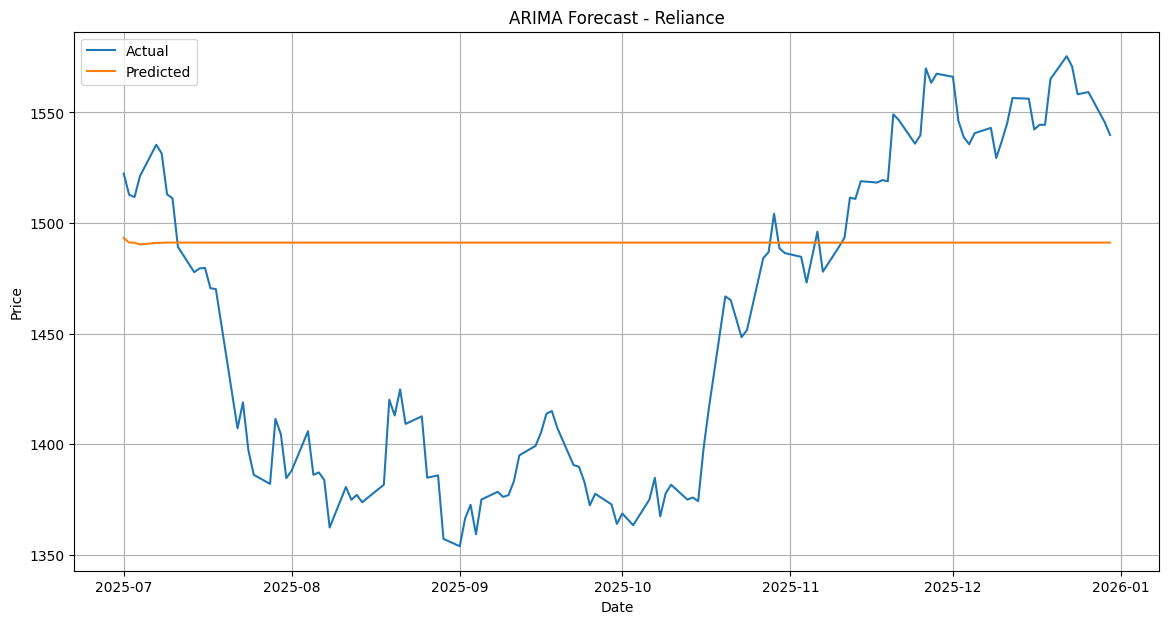


Running ARIMA for Infosys...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


MAPE: 0.0538
RMSE: 93.2729


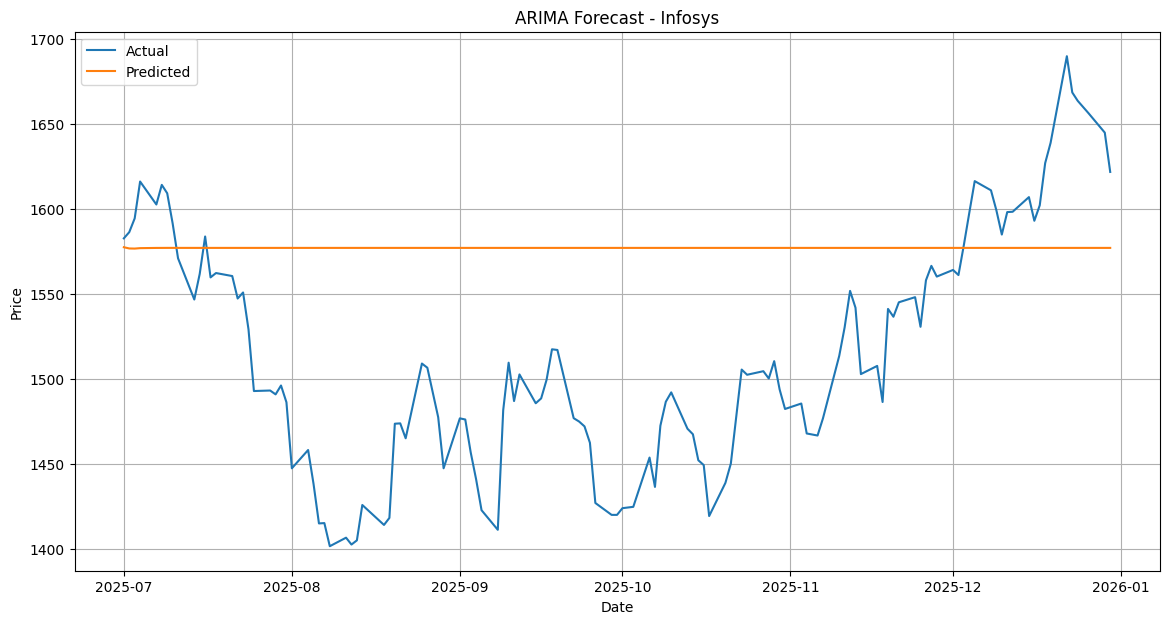


Running ARIMA for HDFC Bank...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


MAPE: 0.0147
RMSE: 19.9018


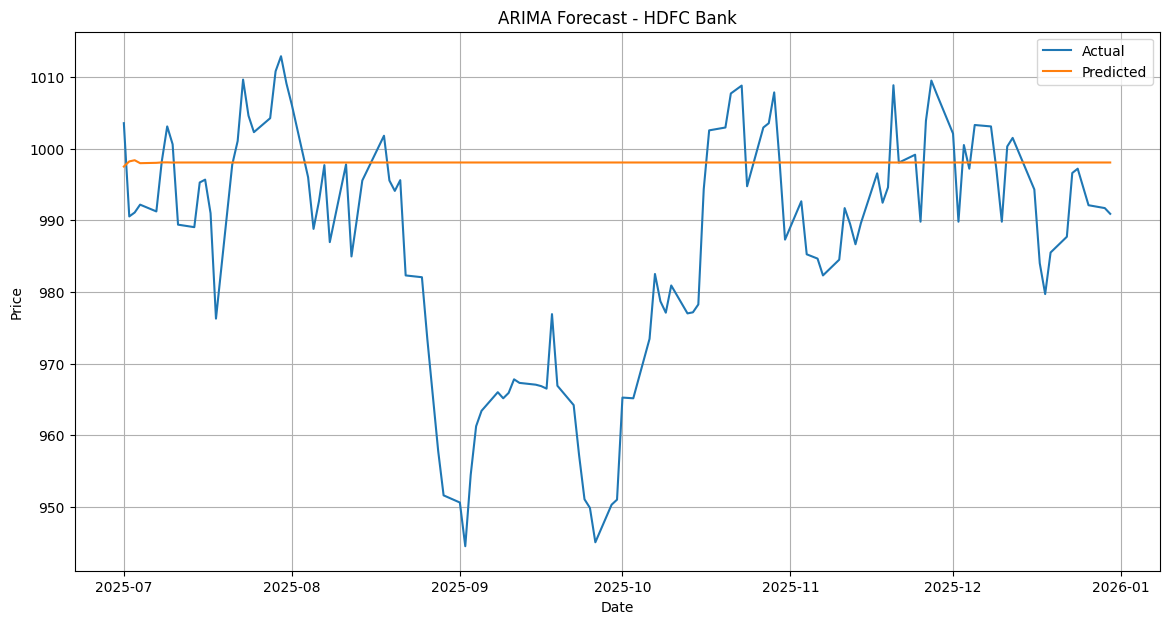


Running ARIMA for Tata Steel...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


MAPE: 0.0517
RMSE: 10.9796


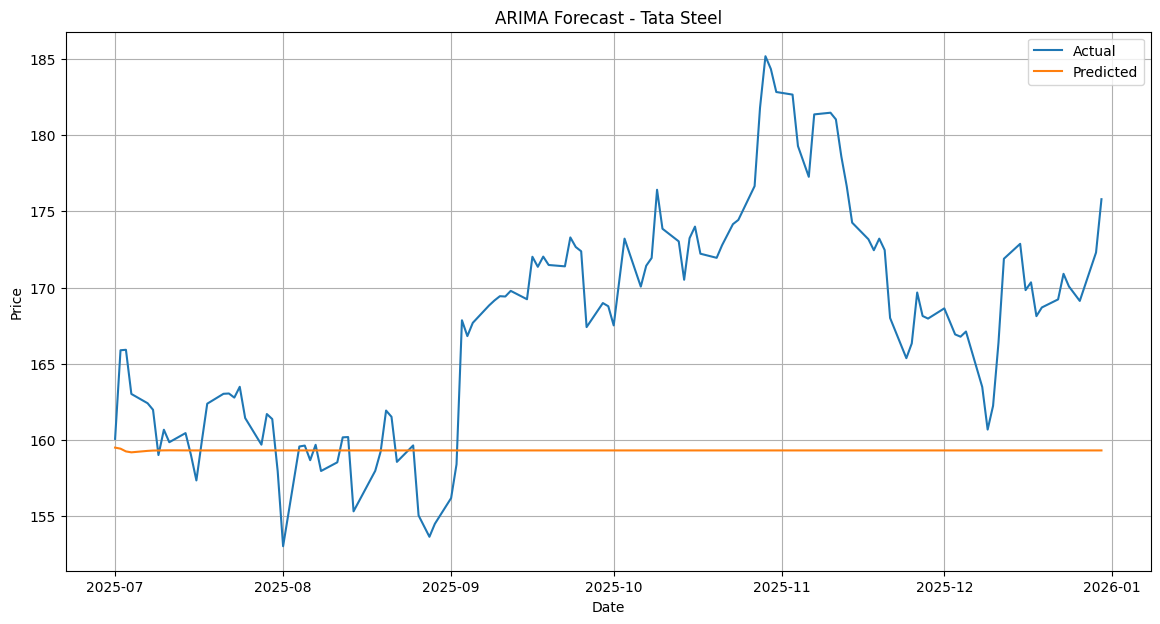


Running ARIMA for Sun Pharma...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


MAPE: 0.0328
RMSE: 68.6894


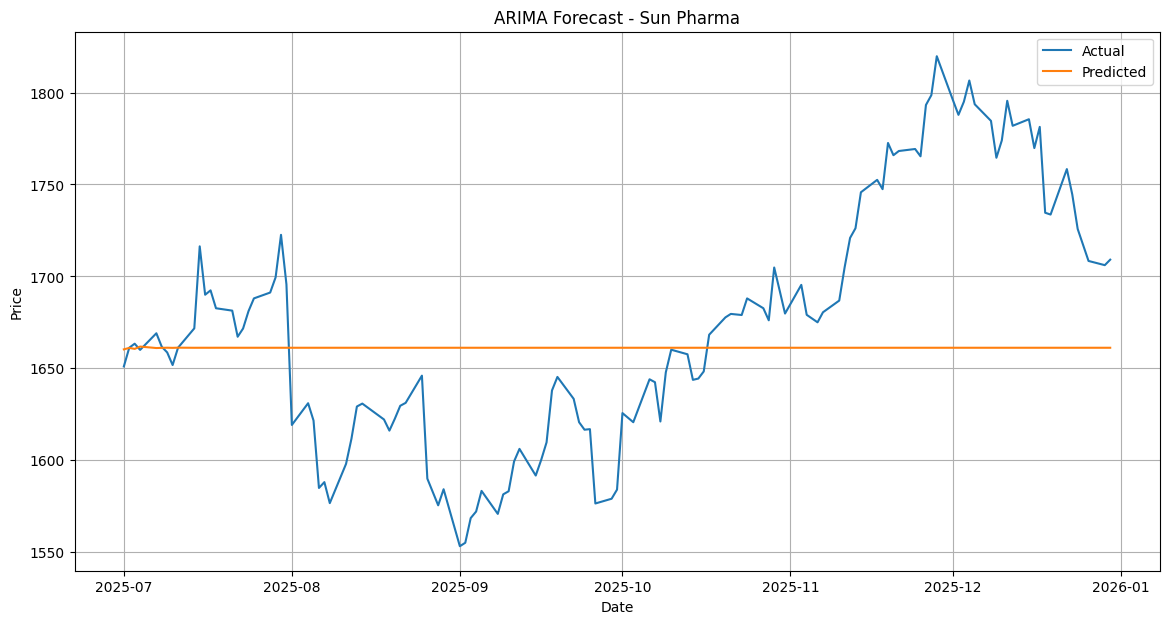

In [6]:
results = {}

for name in stock_data.keys():

    print(f"\nRunning ARIMA for {name}...")

    train = train_data[name]['Close']
    test = test_data[name]['Close']

    # Build ARIMA model
    model = ARIMA(train, order=(5,1,0))
    model_fit = model.fit()

    # Forecast
    forecast = model_fit.forecast(steps=len(test))

    # Metrics
    mape = mean_absolute_percentage_error(test, forecast)
    rmse = np.sqrt(mean_squared_error(test, forecast))

    # Store results
    results[name] = {
        "MAPE": mape,
        "RMSE": rmse
    }

    print(f"MAPE: {mape:.4f}")
    print(f"RMSE: {rmse:.4f}")

    # Plot
    plt.figure(figsize=(14,7))

    plt.plot(test.index, test, label='Actual')
    plt.plot(test.index, forecast, label='Predicted')

    plt.title(f"ARIMA Forecast - {name}")
    plt.xlabel("Date")
    plt.ylabel("Price")

    plt.legend()
    plt.grid(True)

    plt.show()

# 7 — RESULTS TABLE

In [7]:
results_df = pd.DataFrame(results).T

results_df

,MAPE,RMSE
Reliance,0.049351,80.455794
Infosys,0.053796,93.272876
HDFC Bank,0.014714,19.901840
Tata Steel,0.051747,10.979626
Sun Pharma,0.032800,68.689443


In [8]:
results_df = results_df.round(4)

results_df

,MAPE,RMSE
Reliance,0.0494,80.4558
Infosys,0.0538,93.2729
HDFC Bank,0.0147,19.9018
Tata Steel,0.0517,10.9796
Sun Pharma,0.0328,68.6894


# 8 -- PROPHET MODEL

* trend forecasting,
* confidence intervals,
* smoother projections,
* professional-looking visualizations.

## Eg. PROPHET FOR RELIANCE (Debugging)

In [9]:
reliance_data = stock_data["Reliance"].reset_index()

prophet_df = reliance_data[['Date', 'Close']]

prophet_df.columns = ['ds', 'y']

### TRAIN / TEST SPLIT

In [10]:
train_prophet = prophet_df[prophet_df['ds'] < "2025-07-01"]

test_prophet = prophet_df[prophet_df['ds'] >= "2025-07-01"]

### TRAIN MODEL

In [11]:
model = Prophet()

model.fit(train_prophet)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


### CREATE FUTURE DATAFRAME

In [12]:
future = model.make_future_dataframe(periods=len(test_prophet))

forecast = model.predict(future)

### VISUALIZE FORECAST

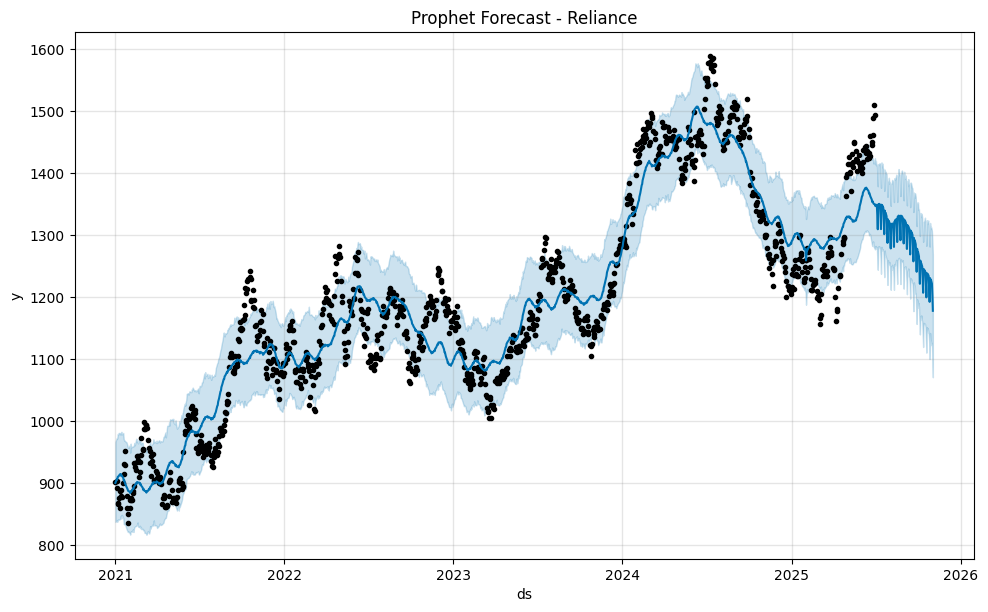

In [13]:
fig = model.plot(forecast)

plt.title("Prophet Forecast - Reliance")

plt.show()

## Automate for All Prophet

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.



Running Prophet for Reliance...
MAPE: 0.1069
RMSE: 191.1608


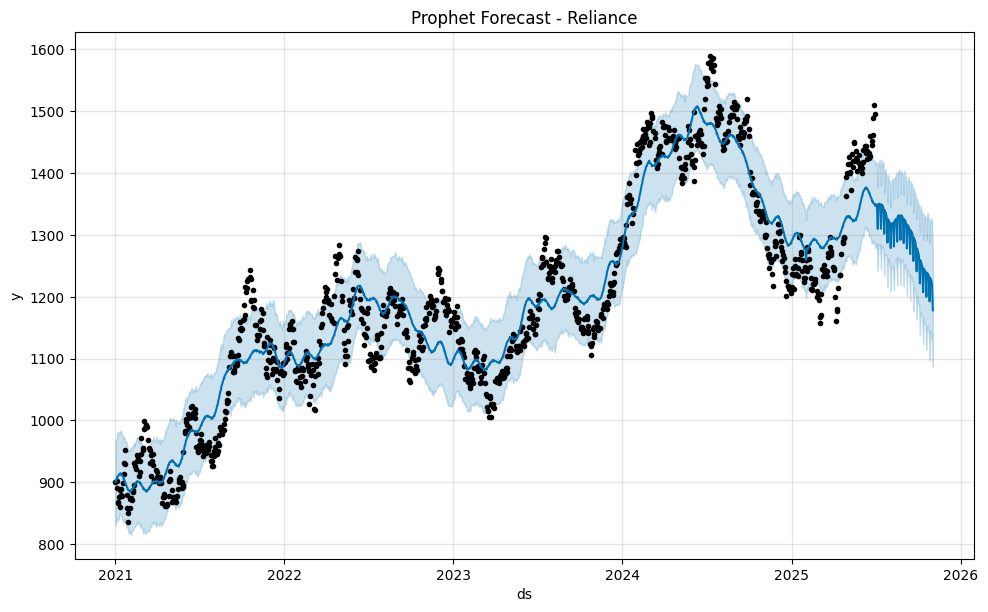

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.



Running Prophet for Infosys...
MAPE: 0.0914
RMSE: 154.7081


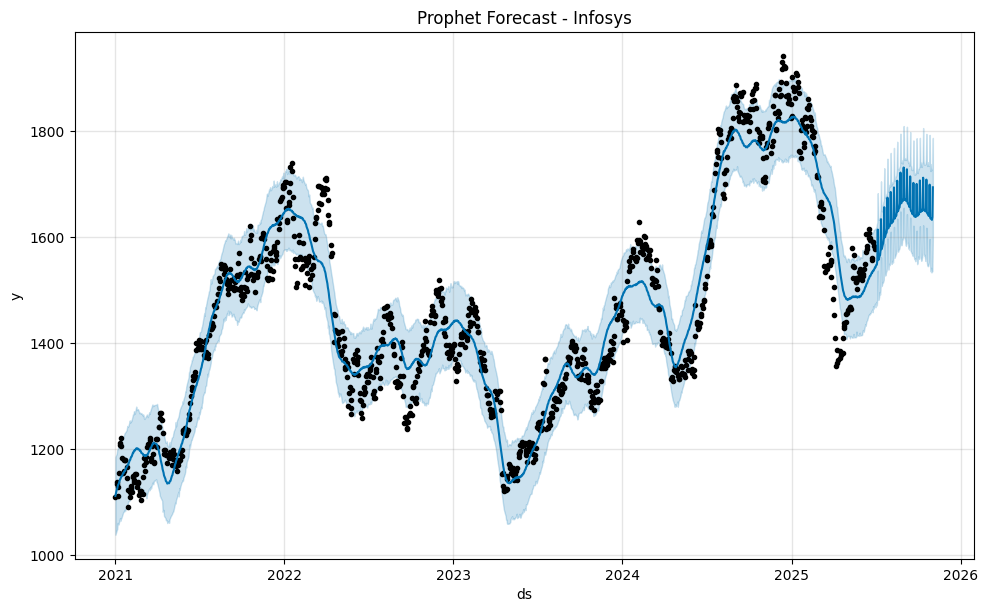

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.



Running Prophet for HDFC Bank...
MAPE: 0.0235
RMSE: 27.3586


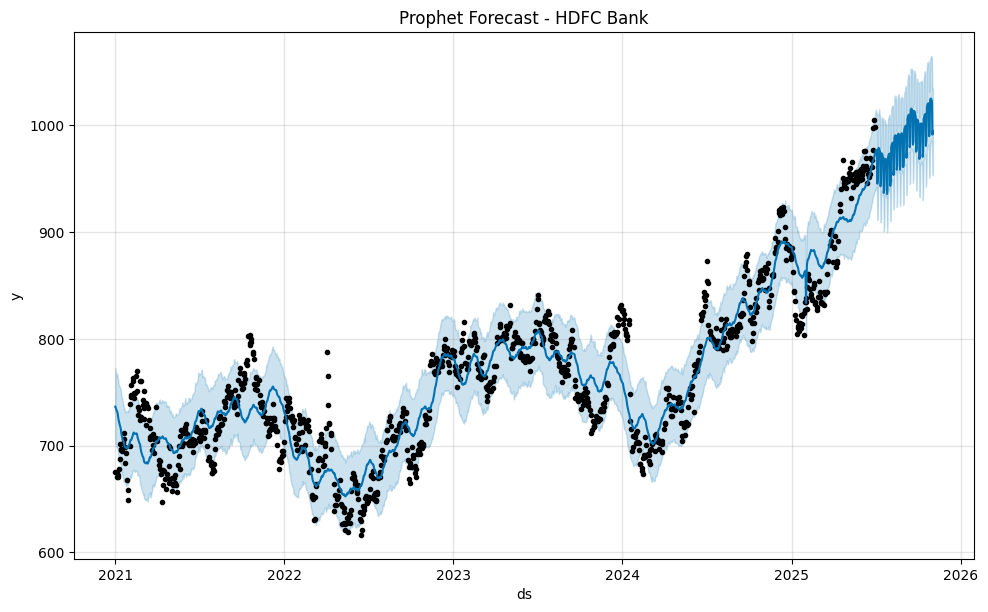

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.



Running Prophet for Tata Steel...
MAPE: 0.1732
RMSE: 31.0838


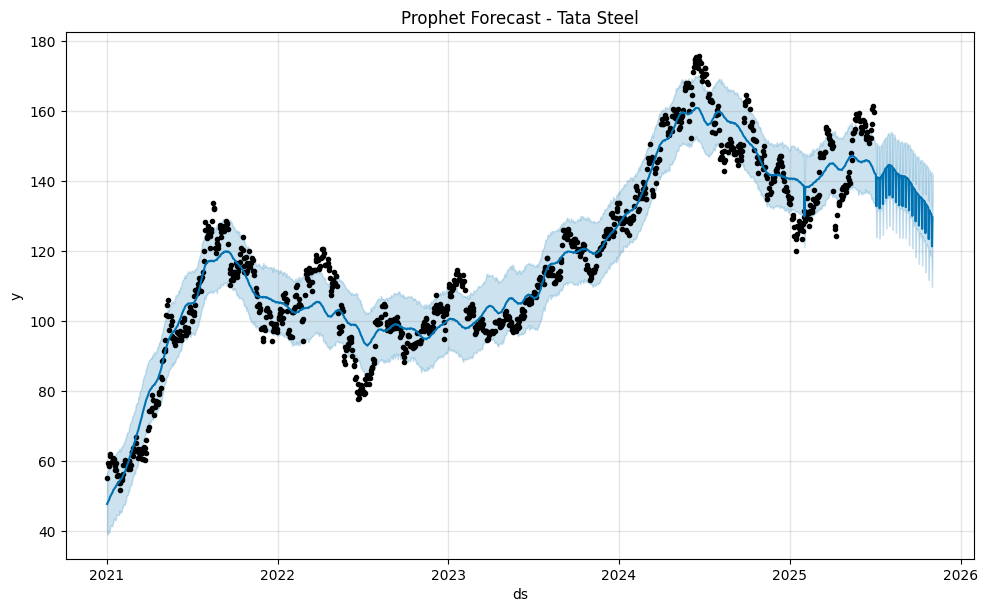

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.



Running Prophet for Sun Pharma...
MAPE: 0.0831
RMSE: 151.8527


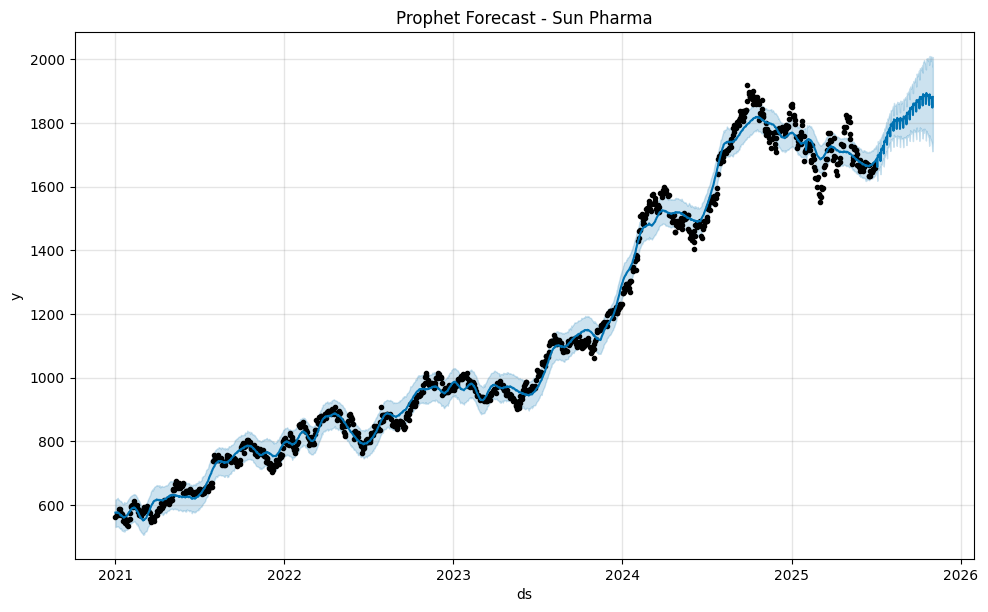

In [14]:
prophet_results = {}

for name, data in stock_data.items():

    print(f"\nRunning Prophet for {name}...")

    # Reset index
    prophet_df = data.reset_index()[['Date', 'Close']]

    # Rename columns
    prophet_df.columns = ['ds', 'y']

    # Train/Test Split
    train = prophet_df[prophet_df['ds'] < "2025-07-01"]
    test = prophet_df[prophet_df['ds'] >= "2025-07-01"]

    # Train model
    model = Prophet()
    model.fit(train)

    # Create future dataframe
    future = model.make_future_dataframe(periods=len(test))

    # Forecast
    forecast = model.predict(future)

    # Extract predictions
    predicted = forecast['yhat'][-len(test):].values
    actual = test['y'].values

    # Metrics
    mape = mean_absolute_percentage_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))

    # Store results
    prophet_results[name] = {
        "MAPE": mape,
        "RMSE": rmse
    }

    print(f"MAPE: {mape:.4f}")
    print(f"RMSE: {rmse:.4f}")

    # Plot forecast
    fig = model.plot(forecast)

    plt.title(f"Prophet Forecast - {name}")

    plt.show()

In [15]:
prophet_results_df = pd.DataFrame(prophet_results).T

prophet_results_df = prophet_results_df.round(4)

prophet_results_df

,MAPE,RMSE
Reliance,0.1069,191.1608
Infosys,0.0914,154.7081
HDFC Bank,0.0235,27.3586
Tata Steel,0.1732,31.0838
Sun Pharma,0.0831,151.8527


# COMPARISON TABLE (Task 6)

In [16]:
comparison_df = pd.DataFrame({
    'ARIMA_MAPE': results_df['MAPE'],
    'ARIMA_RMSE': results_df['RMSE'],
    'Prophet_MAPE': prophet_results_df['MAPE'],
    'Prophet_RMSE': prophet_results_df['RMSE']
})

comparison_df = comparison_df.round(4)

comparison_df

,ARIMA_MAPE,ARIMA_RMSE,Prophet_MAPE,Prophet_RMSE
Reliance,0.0494,80.4558,0.1069,191.1608
Infosys,0.0538,93.2729,0.0914,154.7081
HDFC Bank,0.0147,19.9018,0.0235,27.3586
Tata Steel,0.0517,10.9796,0.1732,31.0838
Sun Pharma,0.0328,68.6894,0.0831,151.8527


# Forecasting Models

## LSTM implementation

### debugging first - Relience

PREPARE DATA

In [17]:
data = stock_data["Reliance"]['Close'].values

data = data.reshape(-1, 1)

SCALE DATA

In [18]:
scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(data)

TRAIN / TEST SPLIT

In [19]:
train_size = int(len(scaled_data) * 0.8)

train_data_lstm = scaled_data[:train_size]
test_data_lstm = scaled_data[train_size:]

CREATE SEQUENCES

In [20]:
def create_sequences(data, seq_length):

    X = []
    y = []

    for i in range(seq_length, len(data)):

        X.append(data[i-seq_length:i, 0])
        y.append(data[i, 0])

    return np.array(X), np.array(y)

GENERATE TRAIN / TEST SEQUENCES

In [21]:
sequence_length = 60

X_train, y_train = create_sequences(train_data_lstm, sequence_length)

X_test, y_test = create_sequences(test_data_lstm, sequence_length)

RESHAPE FOR LSTM

In [22]:
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

### BUILD LSTM MODEL

MODEL ARCHITECTURE

In [23]:
model = Sequential()

model.add(LSTM(50, return_sequences=False, input_shape=(X_train.shape[1], 1)))

model.add(Dense(1))

COMPILE MODEL

In [24]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

TRAIN MODEL

In [25]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0373 - val_loss: 0.0180
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0034 - val_loss: 0.0048
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0022 - val_loss: 0.0026
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0020 - val_loss: 0.0028
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0019 - val_loss: 0.0023
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0018 - val_loss: 0.0022
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0017 - val_loss: 0.0019
Epoch 8/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0017 - val_loss: 0.0022
Epoch 9/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0016 - val_loss: 0.0018
Epoch 10/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0016 - val_loss: 0.0022
Epoch 11/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0015 - val_loss: 0.0017
Epoch 12/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0

PREDICTIONS

In [26]:
predictions = model.predict(X_test)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step


INVERSE SCALING

In [27]:
predictions = scaler.inverse_transform(predictions)

y_test_actual = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

EVALUATION METRICS

In [28]:
mape = mean_absolute_percentage_error(
    y_test_actual,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        predictions
    )
)

print(f"MAPE: {mape:.4f}")
print(f"RMSE: {rmse:.4f}")

MAPE: 0.0164
RMSE: 29.6336


# FINAL COMPARISON TABLE

In [29]:
final_comparison = comparison_df.copy()

final_comparison.loc["Reliance", "LSTM_MAPE"] = round(mape, 4)
final_comparison.loc["Reliance", "LSTM_RMSE"] = round(rmse, 4)
final_comparison = final_comparison.fillna("Not Implemented")


final_comparison

,ARIMA_MAPE,ARIMA_RMSE,Prophet_MAPE,Prophet_RMSE,LSTM_MAPE,LSTM_RMSE
Reliance,0.0494,80.4558,0.1069,191.1608,0.0164,29.6336
Infosys,0.0538,93.2729,0.0914,154.7081,Not Implemented,Not Implemented
HDFC Bank,0.0147,19.9018,0.0235,27.3586,Not Implemented,Not Implemented
Tata Steel,0.0517,10.9796,0.1732,31.0838,Not Implemented,Not Implemented
Sun Pharma,0.0328,68.6894,0.0831,151.8527,Not Implemented,Not Implemented




> Due to the higher computational complexity of deep learning models, LSTM forecasting was implemented on a representative stock series (Reliance Industries) to demonstrate non-linear sequence learning capability.

